# 쇼핑몰 단골 찾기: 공개 거래 분석

UCI Online Retail의 고객 240명을 고정 시드로 추출하고, 그 고객의 유효 구매 이력을 모두 분석했다. **22,488개 상품 행·1,038개 주문·10개 열**이다. 상품 배열은 원본에 없는 사진을 대신해 NumPy 연산을 확인하려고 만든 보조 샘플이며 실제 상품 사진으로 해석하지 않았다. 자세한 출처와 변경 사항은 `data/SOURCE.md`에 정리했다.

In [15]:
from pathlib import Path
import os
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
os.environ['MPLCONFIGDIR'] = str(ROOT / '.cache' / 'matplotlib')
os.environ['XDG_CACHE_HOME'] = str(ROOT / '.cache' / 'xdg')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from src.pipeline import DataAnalyzer
%matplotlib inline
sns.set_theme(style='whitegrid')
FIGURES = ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
print('Python:', sys.version.split()[0], '|', sys.executable)


Python: 3.12.2 | /Users/oliverjoo/Dev/Anaconda/anaconda3/envs/py312/bin/python


## 1. 로드와 기본 탐색

한 주문 번호에 여러 상품 행이 있으므로 행 수와 주문 수를 구분했다. 수치·범주(국가/상품 ID)·날짜·상품명 텍스트를 포함한다. 원본 8열은 `retail_source.csv`에 보관했고, 분석용으로 결제액과 이미지 인덱스를 추가했다. UCI 거래의 통화는 GBP이다.

In [16]:
analyzer = DataAnalyzer(ROOT / 'data/orders.csv', ROOT / 'data/images.npy')
raw = analyzer.load_data().copy()
raw.info()
display(raw.head())
display(raw.describe())
print('Orders:', raw.order_id.nunique(), '| Images:', analyzer.images.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22488 entries, 0 to 22487
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      22488 non-null  int64         
 1   product_id    22488 non-null  object        
 2   product_name  22488 non-null  object        
 3   qty           22488 non-null  int64         
 4   order_date    22488 non-null  datetime64[ns]
 5   price         21364 non-null  float64       
 6   customer_id   22488 non-null  int64         
 7   country       22488 non-null  object        
 8   amount        22488 non-null  float64       
 9   image_index   22488 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 1.7+ MB


,order_id,product_id,product_name,qty,order_date,price,customer_id,country,amount,image_index
0,536376,22114,HOT WATER BOTTLE TEA AND SYMPATHY,48,2010-12-01,NaN,15291,United Kingdom,165.6,766
1,536376,21733,RED HANGING HEART T-LIGHT HOLDER,64,2010-12-01,2.55,15291,United Kingdom,163.2,542
2,536390,22941,CHRISTMAS LIGHTS 10 REINDEER,2,2010-12-01,8.50,17511,United Kingdom,17.0,1475
3,536390,22960,JAM MAKING SET WITH JARS,12,2010-12-01,3.75,17511,United Kingdom,45.0,1493
4,536390,22961,JAM MAKING SET PRINTED,12,2010-12-01,1.45,17511,United Kingdom,17.4,1494


,order_id,qty,order_date,price,customer_id,amount,image_index
count,22488.000000,22488.000000,22488,21364.000000,22488.00000,22488.000000,22488.000000
mean,559608.435655,14.136295,2011-07-02 07:43:01.856990464,3.210772,15565.07862,23.211407,1254.501112
min,536376.000000,1.000000,2010-12-01 00:00:00,0.040000,12381.00000,0.120000,0.000000
25%,549119.000000,2.000000,2011-04-06 00:00:00,1.250000,14565.00000,5.040000,703.750000
50%,560725.000000,6.000000,2011-07-20 00:00:00,1.950000,15291.00000,12.600000,1249.000000
75%,570646.000000,12.000000,2011-10-11 00:00:00,3.750000,16931.00000,19.800000,1775.000000
max,581489.000000,2880.000000,2011-12-09 00:00:00,2033.100000,18270.00000,4176.000000,2600.000000
std,12756.162809,43.307397,NaN,19.371675,1576.18983,67.927950,686.657495


Orders: 1038 | Images: (2601, 8, 8, 3)


**해석:** 22,488행에 주문 1,038개가 들어 있어 행 수로 구매 빈도를 세면 과대계산된다. 고객 번호가 없거나 취소/비양수 거래인 행과 완전 중복은 표본 추출 전에 제외했다. 따라서 결론의 대상은 이 표본의 양의 구매이며 환불을 차감한 순매출은 아니다.

## 2. 그룹별 결측 대치

원본 단가에는 결측이 없어 대치 실습을 위해 1,124행(약 5%)을 고정 시드로 가렸다. 이를 자연적으로 발생한 결측이라고 설명하지 않았다. 같은 상품 ID의 평균 단가로 채우고, 상품 그룹 전체가 비면 전체 평균을 썼다. 원본 단가와 금액은 별도 원본 파일에 남겼다.

In [5]:
missing_before = analyzer.missing_summary()
analyzer.handle_missing_values(column='price', group_col='product_id', strategy='mean')
display(pd.DataFrame({'before': missing_before, 'after': analyzer.missing_summary()}))

,before,after
order_id,0,0
product_id,0,0
product_name,0,0
qty,0,0
order_date,0,0
price,1124,0
customer_id,0,0
country,0,0
amount,0,0
image_index,0,0


**해석:** 가격 결측 1,124개가 0개로 줄어 전체 22,488행을 유지했다. 같은 상품도 시기나 거래 조건에 따라 단가가 달라질 수 있어 대치값을 실제 결제단가라고 보지는 않았다. 매출에는 대치 전 원본 단가로 구한 amount를 사용했다.

## 3. 멀티 모달 피처

상품 2,601개의 보조 RGB 배열(8×8×3)에서 평균·표준편차를 벡터 연산으로 구했다. 배열은 시드가 고정된 픽셀 샘플이며 실제 제품의 시각적 정보를 담지 않는다. 텍스트는 원본 상품명을 공백으로 나눠 단어 수를 계산했다.

In [6]:
analyzer.engineer_features()
display(analyzer.df[['product_name', 'product_word_count', 'image_mean', 'image_std']].head())
display(analyzer.df[['product_word_count', 'image_mean', 'image_std']].describe())

,product_name,product_word_count,image_mean,image_std
0,HOT WATER BOTTLE TEA AND SYMPATHY,6,120.348958,74.830211
1,RED HANGING HEART T-LIGHT HOLDER,5,126.265625,72.349825
2,CHRISTMAS LIGHTS 10 REINDEER,4,128.151042,77.562361
3,JAM MAKING SET WITH JARS,5,122.468750,70.542755
4,JAM MAKING SET PRINTED,4,124.218750,69.854939


,product_word_count,image_mean,image_std
count,22488.000000,22488.000000,22488.000000
mean,4.389497,127.191820,73.683606
std,1.087602,5.517070,2.412824
min,1.000000,108.218750,66.727478
25%,4.000000,123.385417,71.994265
50%,4.000000,127.322917,73.683373
75%,5.000000,130.942708,75.253921
max,8.000000,144.859375,81.732819


**해석:** 이미지 1개당 192개 채널 값을 두 통계량으로 줄여 2,601개 상품에 대응시켰다. 평균 밝기와 표준편차를 계산하는 절차는 확인할 수 있지만 보조 배열이므로 사진 품질이나 매출 효과를 추론할 수 없다.

## 4. IQR 이상치와 전후 비교

Q1−1.5×IQR, Q3+1.5×IQR 경계를 직접 계산했다. 가격만 클리핑하고 상품 행이나 원본 결제액은 보존했다. 아래 전후는 결측 대치 이후와 가격 클리핑 이후의 비교이다. 극단값 때문에 중앙 구간이 눌리지 않도록 박스플롯의 가격 축은 로그 눈금으로 표시했다. 계산에 사용한 가격 자체는 로그 변환하지 않았다.

Bounds: (-2.5, 7.5) | detected: 1971


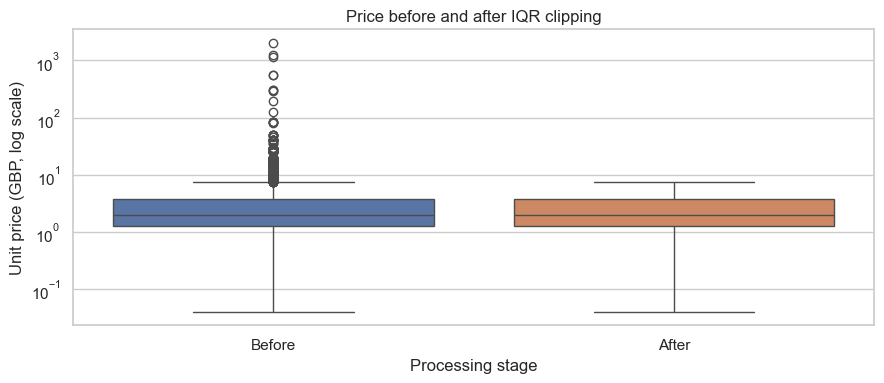

In [7]:
price_before = analyzer.df.price.copy()
print('Bounds:', analyzer.iqr_bounds('price'), '| detected:', len(analyzer.detect_outliers('price')))
analyzer.handle_outliers('price')
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=pd.DataFrame({'Before': price_before, 'After': analyzer.df.price}), ax=ax)
ax.set(title='Price before and after IQR clipping', xlabel='Processing stage', ylabel='Unit price (GBP, log scale)')
ax.set_yscale('log')
fig.tight_layout()
fig.savefig(FIGURES / '02_boxplot.png', dpi=140)
plt.show()

**해석:** 경계는 -2.50~7.50 GBP이며 1,971행(8.76%)을 제한했다. 고가 상품도 이 기준에 걸릴 수 있어 오류라고 단정하지 않았다. 음수 하한은 통계적 경계일 뿐 음수 가격을 허용하는 사업 규칙이 아니다.

## 5. 요약 통계와 상관관계

주문 변수의 표준편차는 ddof=1, 이미지 내부 픽셀은 ddof=0으로 계산했다. 주요 수치 변수의 평균·중앙값·표준편차·Q1/Q3와 Pearson 상관계수를 확인했다.

In [8]:
summary = analyzer.summary_statistics(['price', 'qty', 'amount', 'image_mean', 'image_std'])
correlation = analyzer.df[['price', 'qty', 'amount', 'image_mean']].corr()
display(summary.round(4))
display(correlation.round(4))
summary.to_csv(ROOT / 'reports/summary_statistics.csv')
correlation.to_csv(ROOT / 'reports/correlations.csv')

,mean,median,std,q1,q3
price,2.6395,1.9500,2.1254,1.2500,3.7500
qty,14.1363,6.0000,43.3074,2.0000,12.0000
amount,23.2114,12.6000,67.9279,5.0400,19.8000
image_mean,127.1918,127.3229,5.5171,123.3854,130.9427
image_std,73.6836,73.6834,2.4128,71.9943,75.2539


,price,qty,amount,image_mean
price,1.0000,-0.1633,0.0928,-0.0557
qty,-0.1633,1.0000,0.6689,-0.0208
amount,0.0928,0.6689,1.0000,-0.0433
image_mean,-0.0557,-0.0208,-0.0433,1.0000


**해석:** 가격 평균 2.640, 중앙값 1.95, 표준편차 2.125 GBP이며 Q1=1.25, Q3=3.75이다. 중앙 50%의 구간을 이용해 대표 가격대를 비교할 수 있다. 행별 결제액은 평균 23.211, 중앙값 12.60, 표준편차 67.928 GBP라 큰 금액 행의 영향을 받는다. 수량–결제액 상관 0.669과 가격–결제액 상관 0.093을 비교하면 수량 쪽의 선형 연관이 더 크다. 가격은 클리핑됐고 amount는 원본이므로 상관 해석에도 이 차이를 고려했다.

### 히스토그램

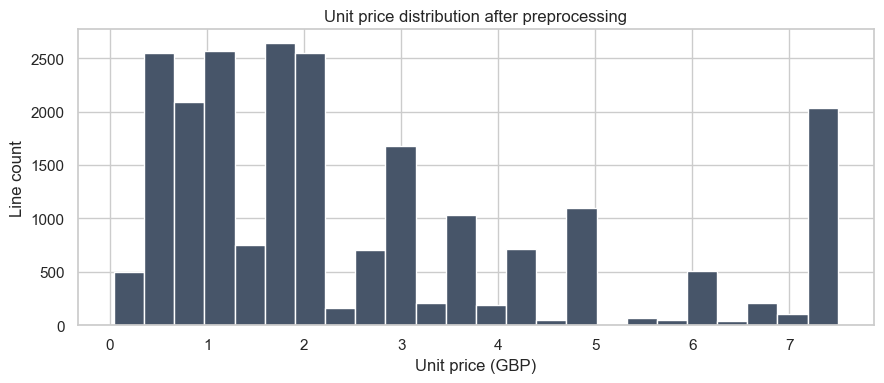

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(analyzer.df.price, bins=24, color='#475569', edgecolor='white')
ax.set(title='Unit price distribution after preprocessing', xlabel='Unit price (GBP)', ylabel='Line count')
fig.tight_layout()
fig.savefig(FIGURES / '01_histogram.png', dpi=140)
plt.show()

**해석:** 상한 7.50 GBP에 1,971개의 제한된 가격이 모인다. 이 봉우리를 자연스러운 가격 수요로 해석하지 않았다.

### 상관 히트맵

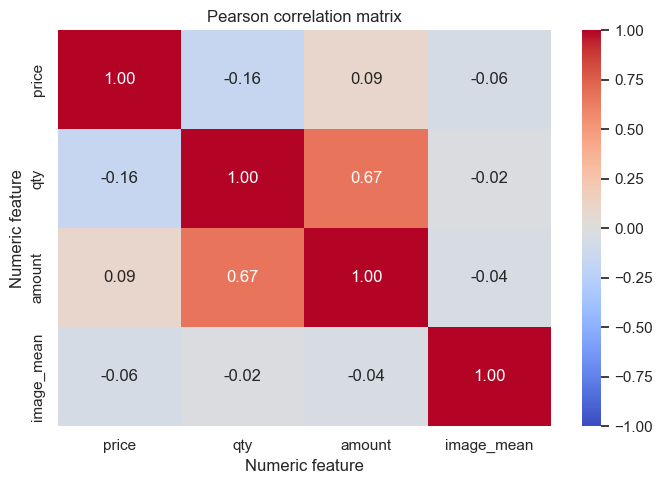

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(correlation, annot=True, fmt='.2f', vmin=-1, vmax=1, center=0, cmap='coolwarm', ax=ax)
ax.set(title='Pearson correlation matrix', xlabel='Numeric feature', ylabel='Numeric feature')
fig.tight_layout()
fig.savefig(FIGURES / '04_heatmap.png', dpi=140)
plt.show()

**해석:** 가격–수량 상관은 -0.163이다. 낮은 단가의 대량 구매 등 여러 요인이 섞일 수 있으므로 가격 인하의 인과효과로 읽지 않았다. 가격–보조 이미지 평균 상관 -0.056에는 상품 사진의 의미가 없다.

### 산점도

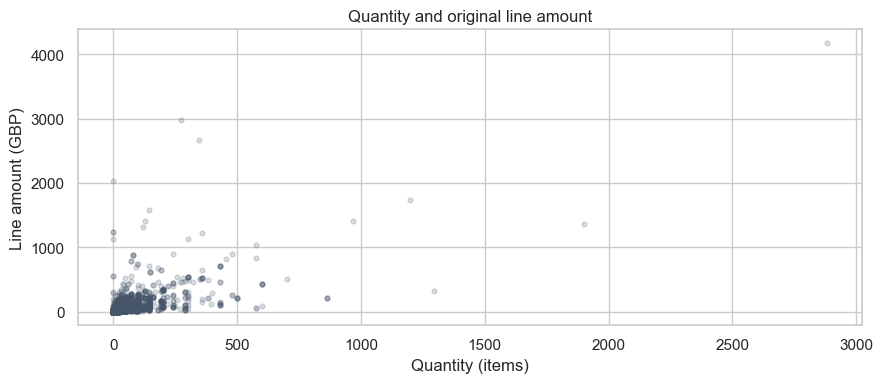

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(analyzer.df.qty, analyzer.df.amount, alpha=0.2, color='#475569', s=12)
ax.set(title='Quantity and original line amount', xlabel='Quantity (items)', ylabel='Line amount (GBP)')
fig.tight_layout()
fig.savefig(FIGURES / '05_scatter.png', dpi=140)
plt.show()

**해석:** 수량 표준편차는 43.31개로 중앙값 6개보다 크다. 대량 주문이 분포를 넓혀 평균 주문만으로 구매 규모를 설명하기 어렵다.

### 월별 매출 라인차트

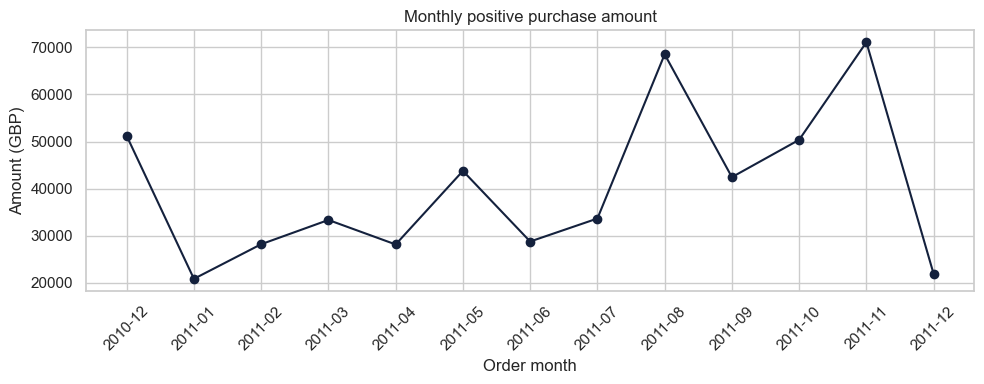

order_date
2010-12    51203.72
2011-01    20801.20
2011-02    28163.18
2011-03    33316.45
2011-04    28112.38
2011-05    43748.72
2011-06    28737.34
2011-07    33626.02
2011-08    68537.01
2011-09    42425.39
2011-10    50365.74
2011-11    71111.12
2011-12    21829.86
Freq: M, Name: amount, dtype: float64

In [12]:
monthly = analyzer.df.groupby(analyzer.df.order_date.dt.to_period('M')).amount.sum()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index.astype(str), monthly.values, marker='o', color='#14213d')
ax.set(title='Monthly positive purchase amount', xlabel='Order month', ylabel='Amount (GBP)')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(FIGURES / '06_line.png', dpi=140)
plt.show()
display(monthly)
monthly.to_csv(ROOT / 'reports/monthly_revenue.csv')

**해석:** 관측은 2010-12-01부터 2011-12-09까지이고 마지막 12월은 9일치이다. 마지막 달의 하락을 월 전체 실적 하락으로 판단하지 않았다. 또한 고객 240명의 표본이므로 회사 전체 매출과 구분했다.

## 6. RFM과 네 고객군

기준일은 표본 최종 구매일 2011-12-09이다. R은 고객 마지막 구매 후 경과일, F는 고유 order_id 수, M은 amount 합계로 계산했다. 점수는 평균 순위 백분위×4를 올림했고 R은 역순으로 정했다. R>90일이면 Churned, R≤30일이고 F/M점수≥3이면 VIP, R≤30일이고 F=1이면 New, 그 외는 Loyal이다. Loyal은 나머지 활동 고객에 붙인 이름이다.

,recency,frequency,monetary,r_score,f_score,m_score,segment
customer_id,,,,,,,
12381,4,5,1845.31,4,4,4,VIP
12449,22,4,4067.29,3,3,4,VIP
12463,53,4,1344.78,2,3,3,Loyal
12510,142,2,982.57,2,2,3,Churned
12530,59,4,1662.28,2,3,3,Loyal


,customers,mean_recency,mean_frequency,mean_monetary,revenue,revenue_share_pct
segment,,,,,,
Churned,86,212.814,1.698,525.162,45163.92,8.652
Loyal,90,45.122,3.267,1210.218,108919.64,20.867
New,6,19.333,1.000,273.732,1642.39,0.315
VIP,58,11.914,10.207,6314.693,366252.18,70.166


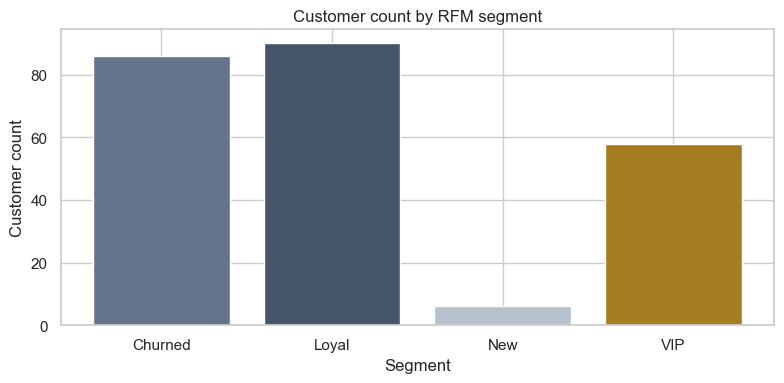

In [13]:
rfm = analyzer.segment_customers(analyzer.calculate_rfm())
segments = rfm.groupby('segment').agg(customers=('recency', 'size'), mean_recency=('recency', 'mean'), mean_frequency=('frequency', 'mean'), mean_monetary=('monetary', 'mean'), revenue=('monetary', 'sum'))
segments['revenue_share_pct'] = segments.revenue / segments.revenue.sum() * 100
display(rfm.head())
display(segments.round(3))
rfm.to_csv(ROOT / 'reports/rfm.csv')
segments.to_csv(ROOT / 'reports/segments.csv')
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(segments.index, segments.customers, color=['#64748b', '#475569', '#b8c2cf', '#a67c20'])
ax.set(title='Customer count by RFM segment', xlabel='Segment', ylabel='Customer count')
fig.tight_layout()
fig.savefig(FIGURES / '03_bar.png', dpi=140)
plt.show()

**해석:** Churned 86명, 평균 R=212.81일, F=1.70회, M=525.16 GBP / Loyal 90명, 평균 R=45.12일, F=3.27회, M=1210.22 GBP / New 6명, 평균 R=19.33일, F=1.00회, M=273.73 GBP / VIP 58명, 평균 R=11.91일, F=10.21회, M=6314.69 GBP이다. 고객군별 다른 재구매 전략을 제안할 수 있지만 이 분류가 미래 구매를 예측한다고 검증한 것은 아니다.

## 7. 보존 검증과 한계

상품 행 22,488개, 주문 1,038개, 양의 구매액 521,978.13 GBP를 보존했다. 이미지와 가격 결측은 계산 실습을 위한 보조 입력이다. 취소/환불을 제외했으므로 금액은 순매출이 아니며 가입일이 없어 가입 월 코호트는 별도 합성 샘플에서만 계산했다.

In [14]:
assert len(raw) == len(analyzer.df)
assert raw.order_id.nunique() == int(rfm.frequency.sum())
assert np.isclose(raw.amount.sum(), rfm.monetary.sum())
assert rfm.segment.nunique() >= 4
assert analyzer.df.price.isna().sum() == 0
print('Line count, unique orders, amount, segments, missing values: PASS')

Line count, unique orders, amount, segments, missing values: PASS
